# JuPedSim Model Comparison Sweep

This notebook compares different pedestrian dynamics models using the same geometry and agent distribution.
 
**Models compared:**

- CollisionFreeSpeedModel: A velocity-based model where agents adjust speed to avoid overlaps.
- GeneralizedCentrifugalForceModel: A force-based model where agents exert "repulsive forces" on one another.

## 1. Load the base scenario

We load a standard corridor or room layout exported from the JuPedSim Web-UI.

In [ ]:
from datetime import datetime

print(f"Executed on {datetime.now().strftime('%d.%m.%Y, %H:%M')}")

from jupedsim_scenarios import load_scenario, run_sweep

base_scenario = load_scenario("scenario_files/template-scenario.zip")
print(base_scenario.summary())

## 2. Execute the Sweep
We iterate through the available models and record the total evacuation time for each.

In [2]:
%%capture
# Sweep the model axis via run_sweep — the library owns per-trial
# scenario isolation (.copy() each), worker dispatch, and result
# tabulation. With three models and workers=3 the trials run in
# parallel.
models = [
    "CollisionFreeSpeedModel",
    "AnticipationVelocityModel",
    "SocialForceModel",
    "WarpDriverModel"
]
sweep = run_sweep(
    base_scenario,
    axes={"model": models},
    apply={"model": lambda s, v: s.set_model_type(v)},
    workers=3,
)
df = sweep.to_dataframe()
sweep.cleanup()

results_by_model = dict(zip(df["model"], df["evacuation_time"], strict=False))
for model, t in results_by_model.items():
    print(f"Model: {model} | Evacuation Time: {t:.2f}s")
    print("=======================\n")

Using fallback logic: No journeys defined
Using fallback logic: No journeys defined
Using fallback logic: No journeys defined
Processing with parameters: {'number': 20, 'radius': 0.2, 'v0': 1.3, 'distribution_mode': 'by_number', 'percentage': None, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
Using default parameters: v0=1.3, radius=0.2, n_agents=20

Processing with parameters: {'number': 20, 'radius': 0.2, 'v0': 1.3, 'distribution_mode': 'by_number', 'percentage': None, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'v0_distribution': 'constant'}
U

## 3. Visualizing Results
Comparison of how the mathematical underlying "logic" of the agents affects the overall efficiency.

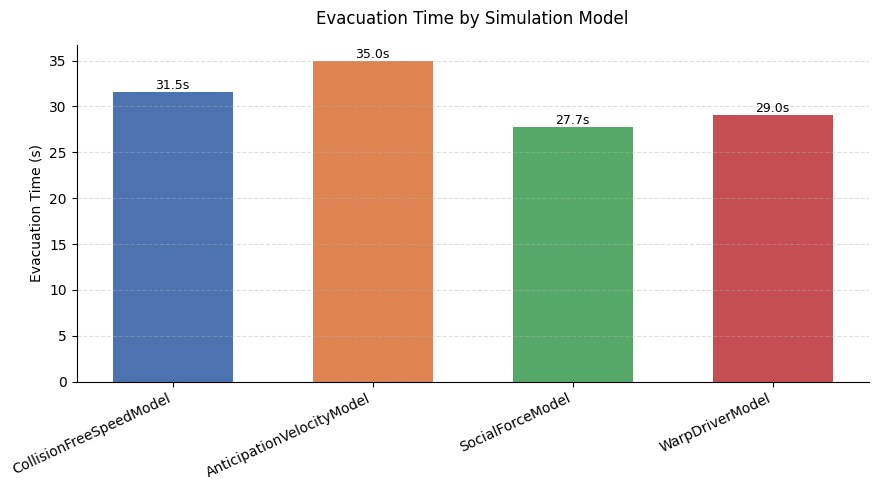

In [3]:
import matplotlib.pyplot as plt

models = list(results_by_model.keys())
times = list(results_by_model.values())

plt.figure(figsize=(9, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = plt.bar(models, times, color=colors[:len(models)], width=0.6)
plt.ylabel("Evacuation Time (s)")
plt.title("Evacuation Time by Simulation Model", pad=15)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}s",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()